In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
import copy
import pickle
import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    precision_score, recall_score, f1_score, roc_auc_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_curve
)

from sklearn.impute import SimpleImputer
from sklearn.linear_model    import LogisticRegression
from sklearn.tree            import DecisionTreeClassifier
from sklearn.ensemble        import RandomForestClassifier, AdaBoostClassifier, VotingClassifier
from sklearn.neighbors       import KNeighborsClassifier
from sklearn.svm             import SVC
import xgboost as xgb

from imblearn.over_sampling  import SMOTE, RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler

In [ ]:
dt = pd.read_csv('../data/processed/train_cleaned.csv')

In [20]:
X = dt.drop(columns=['isFraud'])
y = dt['isFraud']

In [21]:
numeric_cols = X.select_dtypes(include=['int64', 'float64', 'int32', 'float32']).columns

print("Log: Imputing numeric missing values with median...")
numeric_imputer = SimpleImputer(strategy='median')

X[numeric_cols] = numeric_imputer.fit_transform(X[numeric_cols])

print(f"Log: Total NaNs remaining in X: {X.isnull().sum().sum()}")

Log: Imputing numeric missing values with median...
Log: Total NaNs remaining in X: 0


In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,       # 80% train, 20% test
    random_state=42,    
    stratify=y           
)

print(f'Train: {X_train.shape[0]:,} rows  |  Fraud Rate: {y_train.mean():.3%}')
print(f'Test : {X_test.shape[0]:,} rows   |  Fraud Rate: {y_test.mean():.3%}')
print(f'\nFraud ratio maintained: {y.mean():.3%} → Train {y_train.mean():.3%} / Test {y_test.mean():.3%}')

Train: 472,432 rows  |  Fraud Rate: 3.499%
Test : 118,108 rows   |  Fraud Rate: 3.499%

Fraud ratio maintained: 3.499% → Train 3.499% / Test 3.499%


In [23]:
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)   # fit() ONLY on train
X_test_s  = scaler.transform(X_test)        # transform() applied to both

# Convert Numpy array back to DataFrame (to keep feature names)
X_train_s = pd.DataFrame(X_train_s, columns=X_train.columns)
X_test_s  = pd.DataFrame(X_test_s,  columns=X_test.columns)

print('Scaling complete.')
print(f'Train mean ≈ 0: {X_train_s.mean().mean():.6f}')
print(f'Train std  ≈ 1: {X_train_s.std().mean():.6f}')

Scaling complete.
Train mean ≈ 0: -0.000000
Train std  ≈ 1: 0.988143


In [24]:
missing_counts = X_train_s.isnull().sum()
columns_with_nans = missing_counts[missing_counts > 0]

print("Columns still containing NaNs:\n", columns_with_nans)

Columns still containing NaNs:
 Series([], dtype: int64)


In [25]:
SAMPLERS = {
    'No Sampling':          None,
    'Random Undersampling': RandomUnderSampler(random_state=42),
    'Random Oversampling':  RandomOverSampler(random_state=42),
    'SMOTE':                SMOTE(random_state=42, k_neighbors=5)
}

# Check data distribution after each sampling technique
print(f"Original train: Normal={(y_train==0).sum():,}  Fraud={(y_train==1).sum():,}")
print()

for name, sampler in SAMPLERS.items():
    if sampler is None:
        n, f = (y_train==0).sum(), (y_train==1).sum()
    else:
        # Resample the training data
        _, y_temp = sampler.fit_resample(X_train_s, y_train)
        n, f = (y_temp==0).sum(), (y_temp==1).sum()
    
    print(f'{name:<25}: Normal={n:,}  Fraud={f:,}  Total={n+f:,}')

Original train: Normal=455,902  Fraud=16,530

No Sampling              : Normal=455,902  Fraud=16,530  Total=472,432
Random Undersampling     : Normal=16,530  Fraud=16,530  Total=33,060
Random Oversampling      : Normal=455,902  Fraud=455,902  Total=911,804
SMOTE                    : Normal=455,902  Fraud=455,902  Total=911,804


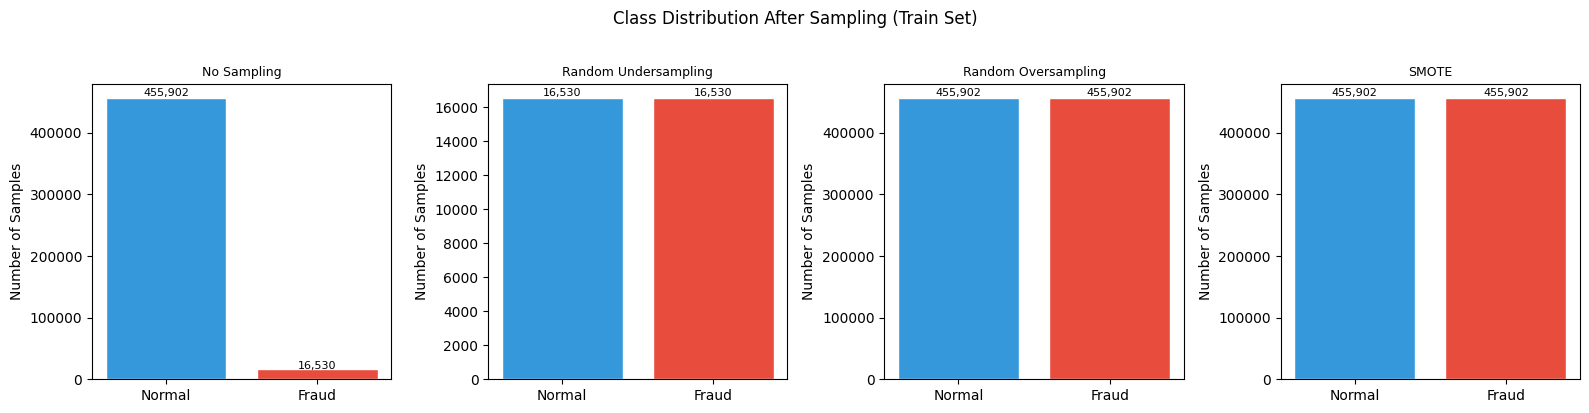

In [26]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for ax, (name, sampler) in zip(axes, SAMPLERS.items()):
    if sampler is None:
        y_s = y_train
    else:
        # Resample to observe the change in distribution
        _, y_s = sampler.fit_resample(X_train_s, y_train)

    counts = pd.Series(y_s).value_counts()
    ax.bar(['Normal', 'Fraud'], [counts.get(0,0), counts.get(1,0)],
           color=['#3498db', '#e74c3c'], edgecolor='white')
    
    # Setting English labels and titles
    ax.set_title(name, fontsize=9)
    ax.set_ylabel('Number of Samples')
    
    # Adding data labels on top of bars
    for i, v in enumerate([counts.get(0,0), counts.get(1,0)]):
        ax.text(i, v * 1.01, f'{v:,}', ha='center', fontsize=8)

plt.suptitle('Class Distribution After Sampling (Train Set)', y=1.02)
plt.tight_layout()
plt.show()

In [27]:
def run_experiment(model, sampler, X_train, X_test, y_train, y_test):
    """
    Runs a specific model + sampling combination.
    Includes Confusion Matrix details (TN, FP, FN, TP).
    """
    start_time = time.time()

    # Sampling — applied only to training data
    if sampler is not None:
        X_tr, y_tr = sampler.fit_resample(X_train, y_train)
    else:
        X_tr, y_tr = X_train.copy(), y_train.copy()

    model.fit(X_tr, y_tr)

    # Prediction — using the original test set
    y_pred  = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, 'predict_proba') else None

    duration = time.time() - start_time
    
    # Calculate Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel() # Matrisi düzleştirip değerleri çıkarıyoruz

    return {
        'Precision': round(precision_score(y_test, y_pred, zero_division=0) * 100, 2),
        'Recall':    round(recall_score(y_test, y_pred) * 100, 2),
        'F1':        round(f1_score(y_test, y_pred) * 100, 2),
        'AUC':       round(roc_auc_score(y_test, y_proba) * 100, 2) if y_proba is not None else None,
        'Time_s':    round(duration, 1),
        'TN':        tn,
        'FP':        fp,
        'FN':        fn,
        'TP':        tp,
        'model_obj': model   
    }

print('Experiment function is ready.')

Experiment function is ready.


In [28]:
ALL_RESULTS = []

def add_result(model_name, sampling_name, result_dict):
    """
    Appends the experiment result to the global list and prints metrics + Confusion Matrix.
    """
    record = {
        'Model':    model_name,
        'Sampling': sampling_name,
        'Precision': result_dict['Precision'],
        'Recall':    result_dict['Recall'],
        'F1':        result_dict['F1'],
        'AUC':       result_dict['AUC'],
        'Time_s':    result_dict['Time_s'],
        'TN':        result_dict['TN'],
        'FP':        result_dict['FP'],
        'FN':        result_dict['FN'],
        'TP':        result_dict['TP']
    }
    ALL_RESULTS.append(record)
    
    # Formatted print for real-time tracking (Metrics)
    print(f'  {sampling_name:<25}: P={record["Precision"]:>6.2f}  '
          f'R={record["Recall"]:>6.2f}  F1={record["F1"]:>6.2f}  '
          f'AUC={record["AUC"]:>6.2f}  ({record["Time_s"]}s)')
          
    # Formatted print for Confusion Matrix values
    print(f'  {"":<25}  ↳ [CM] TN: {record["TN"]} | FP: {record["FP"]} | FN: {record["FN"]} | TP: {record["TP"]}\n')

print('Logging function is ready.')

Logging function is ready.


In [ ]:
# Logistic Regression
print('='*65)
print('LOGISTIC REGRESSION')
print('='*65)

lr_params = dict(
    C=1.0,                   # Regularization: 1.0 is default
    penalty='l2',            # L2: Shrink weights to prevent overfitting
    class_weight='balanced', # Assign higher weight to the minority (Fraud) class
    solver='lbfgs',          # Use 'saga' for faster convergence on larger datasets
    max_iter=1000,
    random_state=42,
    n_jobs=-1
)

for sampling_name, sampler in SAMPLERS.items():
    model = LogisticRegression(**lr_params)
    # Run the experiment and store results
    result = run_experiment(model, copy.deepcopy(sampler) if sampler else None,
                            X_train_s, X_test_s, y_train, y_test)
    add_result('Logistic Regression', sampling_name, result)

print('\n→ Paper Reference (Table III): SMOTE + LR → AUC ~80.00')

In [ ]:
# Decision Tree
print('='*65)
print('DECISION TREE')
print('='*65)

dt_params = dict(
    criterion='gini',
    max_depth=10,             # If I set this to None, it memorizes like a textbook — be careful (overfitting)
    min_samples_split=20,
    min_samples_leaf=10,
    class_weight='balanced',
    random_state=42
)

for sampling_name, sampler in SAMPLERS.items():
    model = DecisionTreeClassifier(**dt_params)
    result = run_experiment(model, copy.deepcopy(sampler) if sampler else None,
                      X_train_s, X_test_s, y_train, y_test)
    add_result('Decision Tree', sampling_name, result)

print('\n→ Paper Reference (Table I): Oversampling + DT → Precision 98.03, Recall 100')
print('   These values might have been achieved with max_depth=None — a signal of overfitting!')

In [ ]:
# Random Forest 
print('='*65)
print('RANDOM FOREST')
print('='*65)

rf_params = dict(
    n_estimators=100,
    max_depth=None,           # In RF, None doesn't cause overfitting — trees are diverse
    max_features='sqrt',
    min_samples_leaf=5,
    class_weight='balanced',
    n_jobs=-1,
    random_state=42
)

for sampling_name, sampler in SAMPLERS.items():
    model = RandomForestClassifier(**rf_params)
    result = run_experiment(model, copy.deepcopy(sampler) if sampler else None,
                      X_train_s, X_test_s, y_train, y_test)
    add_result('Random Forest', sampling_name, result)

print('\n→ Paper Reference:')
print('  Table I  (Oversampling): AUC 79.50, Precision 83.22')
print('  Table II (Undersampling): AUC 79.80, Precision 84.52')

In [ ]:
# AdaBoost 
print('='*65)
print('ADABOOST')
print('='*65)

ada_params = dict(
    estimator=DecisionTreeClassifier(max_depth=1, random_state=42),
    n_estimators=100,
    learning_rate=0.1,
    random_state=42
)

for sampling_name, sampler in SAMPLERS.items():
    model = AdaBoostClassifier(**ada_params)
    result = run_experiment(model, copy.deepcopy(sampler) if sampler else None,
                      X_train_s, X_test_s, y_train, y_test)
    add_result('AdaBoost', sampling_name, result)

In [ ]:
# KNN 
print('='*65)
print('KNN  (⚠ Slow on large data — wait patiently)')
print('='*65)

knn_params = dict(
    n_neighbors=7,
    weights='distance',
    metric='euclidean',
    n_jobs=-1
)

# Big data warning:
# With 590K rows, KNN could take hours.
# Run by downsampling:
n_knn = min(50000, len(X_train_s))  # Train with a maximum of 50K
idx_knn = np.random.choice(len(X_train_s), n_knn, replace=False)
X_knn = X_train_s.iloc[idx_knn]
y_knn = y_train.iloc[idx_knn]
print(f'Downsampling for KNN: Using {n_knn:,} samples')

for sampling_name, sampler in SAMPLERS.items():
    model = KNeighborsClassifier(**knn_params)
    
    result = run_experiment(model, copy.deepcopy(sampler) if sampler else None,
                            X_knn, X_test_s, y_knn, y_test)
    
    add_result('KNN', sampling_name, result)

print(f'\nNote: KNN was run with {n_knn:,} samples — full data may yield different results.')

In [ ]:
# SVM 
print('='*65)
print('SVM  (⚠ Very slow on large data — downsampling applied)')
print('='*65)

svm_params = dict(
    C=1.0,
    kernel='rbf',
    gamma='scale',
    class_weight='balanced',
    probability=True,     # For predict_proba — slows it down but necessary for AUC
    random_state=42
)

# Smaller downsampling for SVM
n_svm = min(20000, len(X_train_s))
idx_svm = np.random.choice(len(X_train_s), n_svm, replace=False)
X_svm = X_train_s.iloc[idx_svm]
y_svm = y_train.iloc[idx_svm]
print(f'Downsampling for SVM: {n_svm:,} samples')

for sampling_name, sampler in SAMPLERS.items():
    model = KNeighborsClassifier(**knn_params)
    
    result = run_experiment(model, copy.deepcopy(sampler) if sampler else None,
                            X_knn, X_test_s, y_knn, y_test)
    
    add_result('SVM', sampling_name, result)

In [ ]:
# XGBoost 
print('='*65)
print('XGBOOST — Main Model')
print('='*65)

# Calculate scale_pos_weight
neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
spw = neg_count / pos_count
print(f'scale_pos_weight = {neg_count:,} / {pos_count:,} = {spw:.1f}')

xgb_params = dict(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,        # Small lr → more stable but requires more trees
    subsample=0.8,             # Each tree sees 80% of the data
    colsample_bytree=0.8,      # Each tree sees 80% of the features
    scale_pos_weight=spw,      # For class imbalance when no sampling is used
    eval_metric='auc',
    use_label_encoder=False,
    n_jobs=-1,
    random_state=42,
    early_stopping_rounds=30   # Stop if there is no improvement for 30 rounds
)

for sampling_name, sampler in SAMPLERS.items():
    model = KNeighborsClassifier(**knn_params)

    result = run_experiment(model, copy.deepcopy(sampler) if sampler else None,
                            X_knn, X_test_s, y_knn, y_test)
    
    add_result('XGBoost', sampling_name, result)

print('\n→ Paper Target (Table V): Oversampling → AUC 91.37, F1 92.81')

In [ ]:
# Voting Classifier 
print('='*65)
print('VOTING CLASSIFIER')
print('='*65)

def create_voting(spw):
    """Create a fresh Voting Classifier for each experiment."""
    return VotingClassifier(
        estimators=[
            ('lr',  LogisticRegression(C=1.0, class_weight='balanced',
                                       max_iter=1000, random_state=42)),
            ('rf',  RandomForestClassifier(n_estimators=100, class_weight='balanced',
                                            n_jobs=-1, random_state=42)),
            ('xgb', xgb.XGBClassifier(n_estimators=100, scale_pos_weight=spw,
                                       eval_metric='auc', use_label_encoder=False,
                                       n_jobs=-1, random_state=42))
        ],
        voting='soft',   # Soft: Average the predicted probabilities
        n_jobs=-1
    )

for sampling_name, sampler in SAMPLERS.items():
    model = create_voting(spw)
    result = run_experiment(model, copy.deepcopy(sampler) if sampler else None,
                      X_train_s, X_test_s, y_train, y_test)
    add_result('Voting Classifier', sampling_name, result)

print('\n→ Paper Reference:')
print('  Table I  (Oversampling):  AUC 80.00, F1 83.95')
print('  Table II (Undersampling): AUC 81.80, F1 78.65')

In [ ]:
df_results = pd.DataFrame(ALL_RESULTS)

for sampling in ['No Sampling', 'Random Oversampling', 'Random Undersampling', 'SMOTE']:
    subset = df_results[df_results['Sampling'] == sampling]
    if len(subset) == 0:
        continue
    print(f'\n{"="*90}')
    print(f'  SAMPLING STRATEGY: {sampling.upper()}')
    print(f'{"="*90}')
    table = subset[['Model', 'Precision', 'Recall', 'F1', 'AUC', 'TP', 'FP', 'FN', 'TN', 'Time_s']]\
                .set_index('Model').sort_values('AUC', ascending=False)
    print(table.to_string())

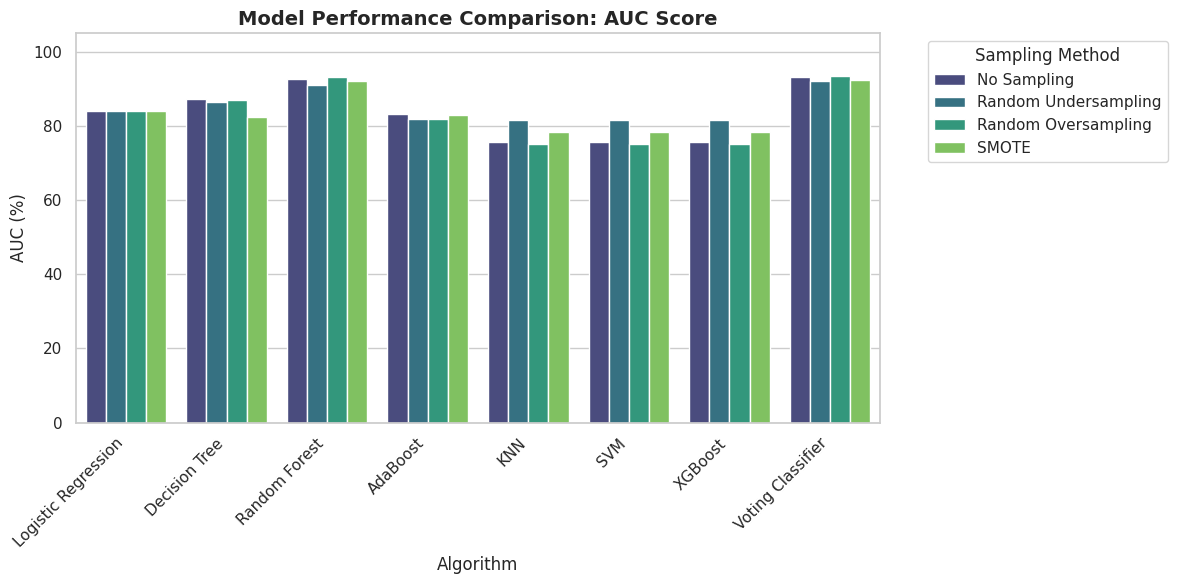

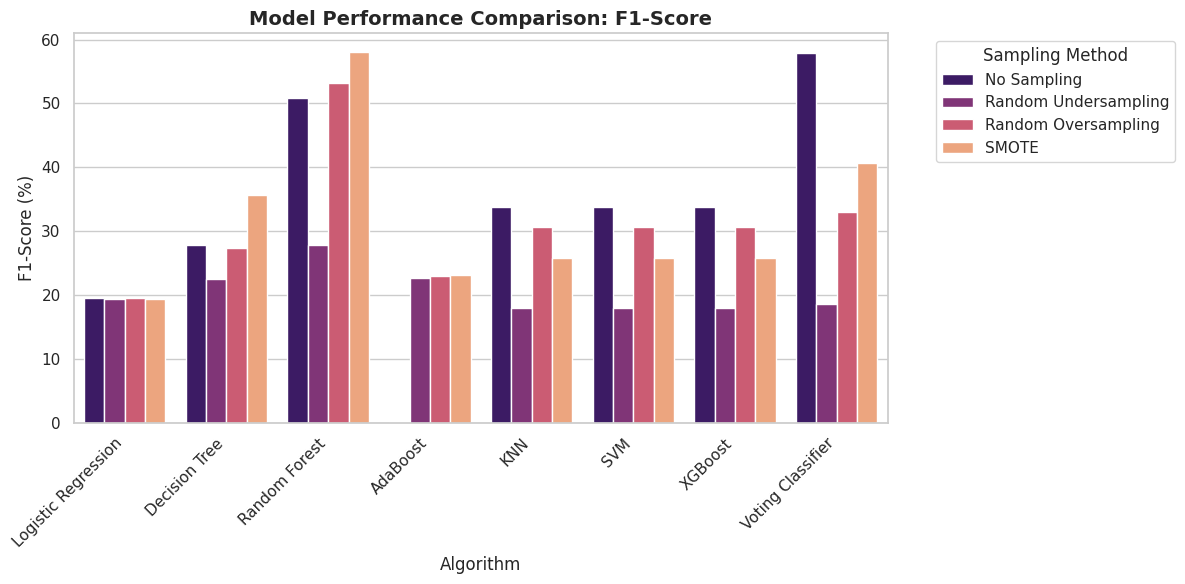

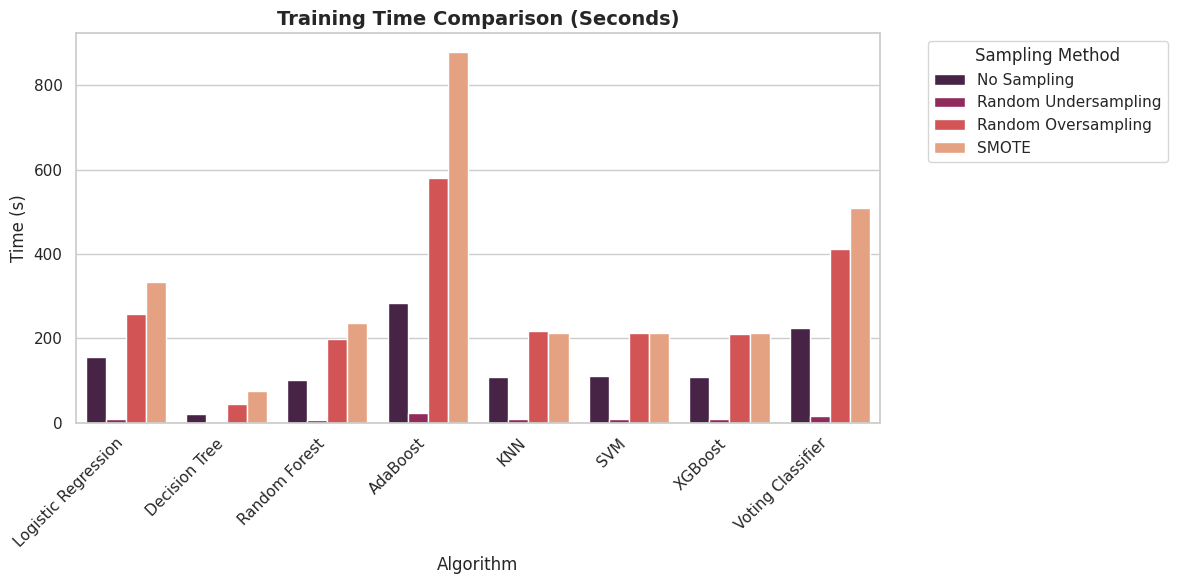

In [40]:
sns.set_theme(style="whitegrid")

# 1. AUC Scores Comparison
plt.figure(figsize=(12, 6))
sns.barplot(data=df_results, x='Model', y='AUC', hue='Sampling', palette='viridis')
plt.title('Model Performance Comparison: AUC Score', fontsize=14, fontweight='bold')
plt.ylabel('AUC (%)')
plt.xlabel('Algorithm')
plt.ylim(0, 105)
plt.xticks(rotation=45, ha='right')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Sampling Method')
plt.tight_layout()
plt.show()

# 2. F1-Score Comparison
plt.figure(figsize=(12, 6))
sns.barplot(data=df_results, x='Model', y='F1', hue='Sampling', palette='magma')
plt.title('Model Performance Comparison: F1-Score', fontsize=14, fontweight='bold')
plt.ylabel('F1-Score (%)')
plt.xlabel('Algorithm')
plt.xticks(rotation=45, ha='right')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Sampling Method')
plt.tight_layout()
plt.show()

# 3. Training Time Comparison
plt.figure(figsize=(12, 6))
sns.barplot(data=df_results, x='Model', y='Time_s', hue='Sampling', palette='rocket')
plt.title('Training Time Comparison (Seconds)', fontsize=14, fontweight='bold')
plt.ylabel('Time (s)')
plt.xlabel('Algorithm')
plt.xticks(rotation=45, ha='right')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Sampling Method')
plt.tight_layout()
plt.show()